In [28]:
# Notebook 全局超参数。只改这一格，然后从上到下重新运行整个 notebook。
from skopt.space import Categorical, Integer, Real

NOTEBOOK_RUN_MODE = "smoke"  # "smoke" or "full"
NOTEBOOK_SAMPLE_SIZE = 1024 if NOTEBOOK_RUN_MODE == "smoke" else 0
NOTEBOOK_BAYES_N_ITER = 2 if NOTEBOOK_RUN_MODE == "smoke" else 32
NOTEBOOK_CV_FOLDS = 2 if NOTEBOOK_RUN_MODE == "smoke" else 5
NOTEBOOK_RANDOM_SEED = 114514
NOTEBOOK_TEST_SIZE = 0.2
NOTEBOOK_MODEL_N_JOBS = 1
NOTEBOOK_SEARCH_N_JOBS = 1
NOTEBOOK_SMOTE_K_NEIGHBORS = 5
NOTEBOOK_BAYES_SCORING = "roc_auc"
NOTEBOOK_BAYES_VERBOSE = 1

NOTEBOOK_FULL_SEARCH_SPACES = {
    "num_leaves": Integer(15, 255),
    "learning_rate": Real(1e-4, 1e-2, prior="log-uniform"),
    "n_estimators": Integer(200, 500),
    "max_depth": Categorical([-1, 3, 5, 7, 9, 12, 15]),
    "subsample": Real(0.2, 1.0),
    "colsample_bytree": Real(0.2, 1.0),
    "min_child_samples": Integer(5, 50),
}

NOTEBOOK_LGBM_SEARCH_SPACES = (
    NOTEBOOK_SMOKE_SEARCH_SPACES
    if NOTEBOOK_RUN_MODE == "smoke"
    else NOTEBOOK_FULL_SEARCH_SPACES
)


In [29]:
data['RETENTION_TIME'] = pd.to_numeric(data['RETENTION_TIME'], errors='coerce').astype('float64')
print("转换前 RETENTION_TIME 的示例值：")
print(data['RETENTION_TIME'].head())

non_numeric = pd.to_numeric(data['RETENTION_TIME'], errors='coerce').isna()
print()
print("非数值数据数量：", non_numeric.sum())
print("非数值数据示例：")
print(data[non_numeric]['RETENTION_TIME'].unique())
    


转换前 RETENTION_TIME 的示例值：
0    8.500
1    5.800
2    8.300
3    9.900
4    5.304
Name: RETENTION_TIME, dtype: float64

非数值数据数量： 175
非数值数据示例：
[nan]


In [30]:
print("样本总数:", len(data))
print("标签分布:")
data[DEFAULT_TARGET_COLUMN].value_counts()
            


样本总数: 1024
标签分布:


0    665
1    359
Name: 毒性, dtype: int64

In [31]:
print("过采样方法:", "notebook_smote")
print("过采样后的训练集形状:", X_train.shape)
print("测试集形状:", X_test.shape)
print("过采样后的标签分布:", pd.Series(y_train).value_counts())
            


过采样方法: notebook_smote
过采样后的训练集形状: (1068, 14)
测试集形状: (205, 14)
过采样后的标签分布: 1    534
0    534
Name: 毒性, dtype: int64


## LightGBM（CUDA-only）

- 顶部 smoke validation 单元已经完成数据加载、特征预处理、CUDA 预检和一次 BayesSearchCV 训练。
- 训练设备固定为 `cuda`，禁止 CPU fallback。
- 所有 notebook 超参数都在最顶部的全局配置单元里集中定义；修改 `NOTEBOOK_*` 变量后，从该单元开始重新运行即可。
- `NOTEBOOK_CONFIG` 由这些全局变量构建，`NOTEBOOK_LGBM_SEARCH_SPACES` 也在同一处统一维护。
- Notebook 默认使用 `smoke` 模式做轻量验证；把 `NOTEBOOK_RUN_MODE` 改为 `"full"` 可切换为全量训练。
- 训练前会执行一次 CUDA 预检；如果当前 `lightgbm` 不是带 CUDA 的构建，会直接报错并停止。
- 官方当前不支持 Windows 上的 CUDA 版 LightGBM。需要把训练移动到 Linux 或 WSL2，并先执行：

```bash
pip uninstall -y lightgbm
pip install lightgbm --no-binary lightgbm --config-settings=cmake.define.USE_CUDA=ON
```


In [24]:
print("LightGBM CUDA preflight:", lgbm_version)
print("最佳参数组合:", bayes_search.best_params_)
print("最佳验证集AUC:", bayes_search.best_score_)
for metric, value in smoke_metrics.items():
    print(f"Smoke {metric}: {value:.6f}")
print("测试集混淆矩阵:")
print(smoke_confusion_matrix)
            


LightGBM CUDA preflight: 4.6.0
最佳参数组合: OrderedDict([('colsample_bytree', 0.5245194901382664), ('learning_rate', 0.006188952043698076), ('max_depth', 3), ('min_child_samples', 5), ('n_estimators', 50), ('num_leaves', 27), ('subsample', 0.786208069713018)])
最佳验证集AUC: 0.736659028112802
Smoke AUC: 0.655347
Smoke Accuracy: 0.650485
Smoke Balanced Accuracy: 0.627049
Smoke Precision: 0.583333
Smoke Recall: 0.500000
Smoke F1: 0.538462
Smoke Specificity: 0.754098
测试集混淆矩阵:
[[46 15]
 [21 21]]



=== 训练集性能 ===
AUC               : 0.9357
Accuracy          : 0.8593
Balanced Accuracy : 0.8593
Precision         : 0.8455
Recall            : 0.8791
F1                : 0.8620
Specificity       : 0.8394

=== 测试集性能 ===
AUC               : 0.6553
Accuracy          : 0.6505
Balanced Accuracy : 0.6270
Precision         : 0.5833
Recall            : 0.5000
F1                : 0.5385
Specificity       : 0.7541

测试集混淆矩阵:
[[46 15]
 [21 21]]


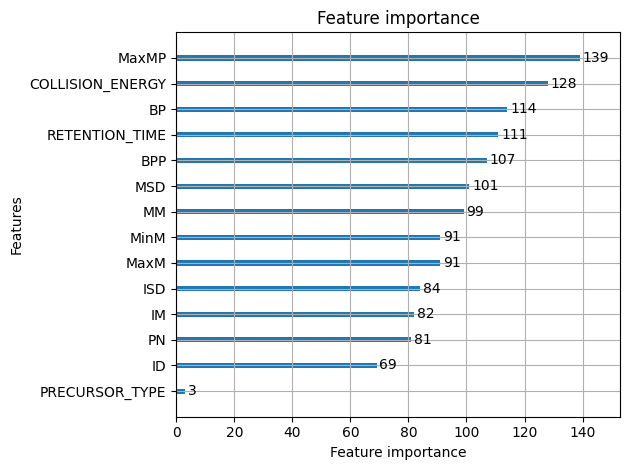

In [25]:
# 使用最佳参数训练模型
best_lgb = bayes_search.best_estimator_

# ============ 训练集评估 ============
y_train_pred = best_lgb.predict(X_train)
y_train_proba = best_lgb.predict_proba(X_train)[:, 1]

train_metrics = {
    'AUC': roc_auc_score(y_train, y_train_proba),
    'Accuracy': accuracy_score(y_train, y_train_pred),
    'Balanced Accuracy': balanced_accuracy_score(y_train, y_train_pred),
    'Precision': precision_score(y_train, y_train_pred),
    'Recall': recall_score(y_train, y_train_pred),
    'F1': f1_score(y_train, y_train_pred)
}

tn, fp, fn, tp = confusion_matrix(y_train, y_train_pred).ravel()
train_metrics['Specificity'] = tn / (tn + fp)

# ============ 测试集评估 ============
y_test_pred = best_lgb.predict(X_test)
y_test_proba = best_lgb.predict_proba(X_test)[:, 1]

test_metrics = {
    'AUC': roc_auc_score(y_test, y_test_proba),
    'Accuracy': accuracy_score(y_test, y_test_pred),
    'Balanced Accuracy': balanced_accuracy_score(y_test, y_test_pred),
    'Precision': precision_score(y_test, y_test_pred),
    'Recall': recall_score(y_test, y_test_pred),
    'F1': f1_score(y_test, y_test_pred)
}

tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
test_metrics['Specificity'] = tn / (tn + fp)

print()
print("=== 训练集性能 ===")
for metric, value in train_metrics.items():
    print(f"{metric:<18}: {value:.4f}")

print()
print("=== 测试集性能 ===")
for metric, value in test_metrics.items():
    print(f"{metric:<18}: {value:.4f}")

print()
print("测试集混淆矩阵:")
print(confusion_matrix(y_test, y_test_pred))

lgb.plot_importance(best_lgb, max_num_features=20)
plt.tight_layout()
plt.show()
    
